# Diagrama de arquitectura del modelo convolucional 1D

Figura de la arquitectura del modelo entrenado en `cnn_v1_training.ipynb`, para la memoria. Es un **esquema por etapas**, con el mismo planteamiento que el de la v2: una caja por etapa, no por capa, porque una caja por capa sale como una tira demasiado apaisada para una página.

El esquema se escribe en Graphviz, que ya entra con `pydot`. La estructura es la de `cnn_v1_training.ipynb`, así que hay que repasarla si cambia la red.

In [1]:
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

MODELS_DIR = SOLUTION_DIR / "models"
CNN_DIR = MODELS_DIR / "cnn"

# Modelo a dibujar y figura que genera este cuaderno
MODEL_PATH = CNN_DIR / "cnn_v1.keras"
DIAGRAM_PATH = CNN_DIR / "cnn_v1_architectural-diagram.png"

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


El `.keras` guarda la arquitectura junto con los pesos. El resumen no genera la figura —el esquema está escrito a mano—, pero sirve para comprobar contra el modelo entrenado las formas y el número de filtros que rotula el diagrama.

In [2]:
import tensorflow as tf

model_cnn = tf.keras.models.load_model(MODEL_PATH)

model_cnn.summary()

2026-08-30 22:53:09.065429: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-30 22:53:09.231035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-30 22:53:12.340104: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2026-08-30 22:53:13.917884: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_residual_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2666, 64)  │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2666, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2666, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2666, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2666, 64)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2666, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2666, 1)   │        321 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 2666, 1)   │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_9[0][0]  

 Total params: 692,549 (2.64 MB)

 Trainable params: 230,849 (901.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 461,700 (1.76 MB)

Cómo se lee el esquema:

- La red trabaja siempre sobre la malla de SDSS, sin submuestrear: los 2666 puntos se conservan de principio a fin, y por eso el esquema es una cadena y no una U como el de la v2.
- Tras la convolución inicial de 64 filtros vienen los **cuatro bloques residuales**, todos iguales, que la figura agrupa en una sola caja: lo que cambia entre ellos son los pesos, no la forma.
- La convolución final de un filtro genera la **corrección**, y la **conexión residual global** —la flecha discontinua— le suma el flujo interpolado: la red aprende la corrección, no el espectro entero.

El recuadro de la derecha desarrolla uno de los bloques residuales: las dos convoluciones, el atajo que se les suma y la activación.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1_architectural-diagram.png
Tamaño: (2677, 332) px


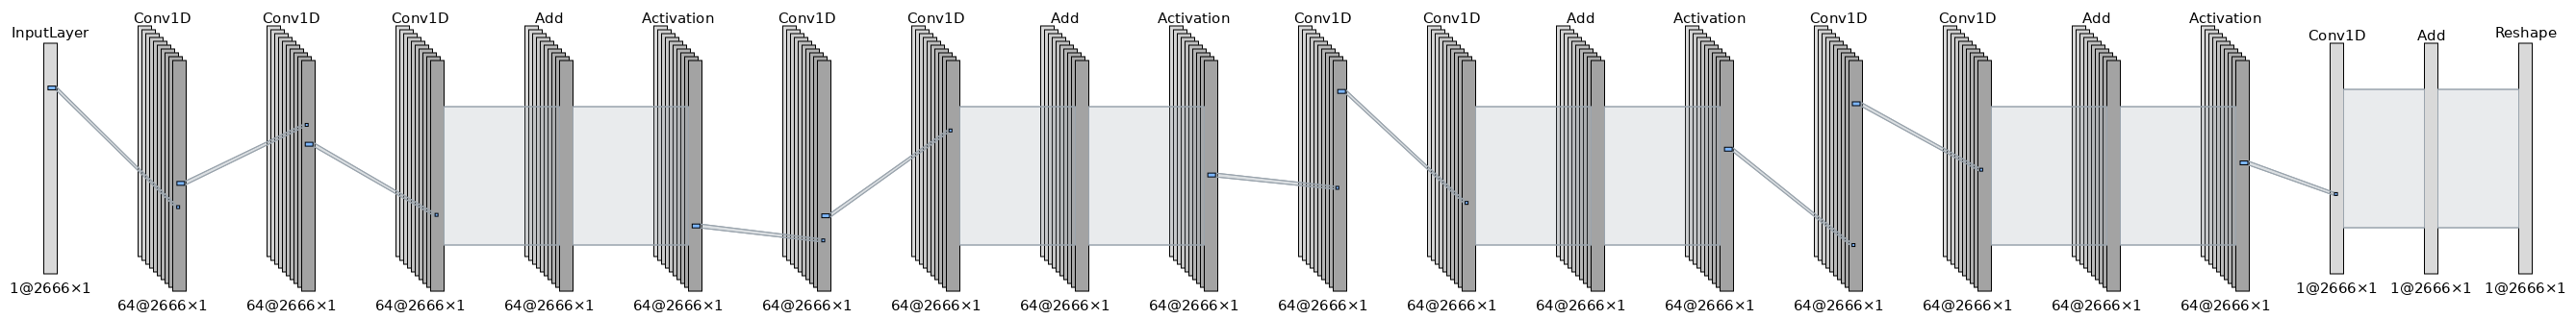

In [3]:
import pydot

from IPython.display import Image

DOT = """digraph cnn_residual {
    rankdir=TB
    bgcolor="white"
    splines=polyline
    dpi=150
    nodesep=0.35
    ranksep=0.45
    node [shape=box style="rounded,filled" fillcolor="#eef2f7" color="#5b6b7c"
          fontname="DejaVu Sans" fontsize=11 margin="0.18,0.10"]
    edge [fontname="DejaVu Sans" fontsize=9 color="#5b6b7c"]

    entrada [label="flujo interpolado\n2666 × 1" fillcolor="#dfe7ef"]
    conv0   [label="Conv1D 64 (k9) + ELU\n64 @ 2666"]
    bloques [label="4 × bloque residual\n64 @ 2666" fillcolor="#d7e3f0"]
    conv1   [label="Conv1D 1 (k5)\ncorrección, 2666"]
    salida  [label="⊕ flujo interpolado\n2666" fillcolor="#dfe7ef"]

    entrada -> conv0 -> bloques -> conv1 -> salida
    entrada -> salida [constraint=false style=dashed color="#9aa4ad"
                       label="  conexión residual global"]

    subgraph cluster_bloque {
        label="bloque residual"
        fontname="DejaVu Sans" fontsize=11 fontcolor="#5b6b7c"
        color="#c3ccd6" style=rounded margin=12

        b_in  [label="x\n64 @ 2666" fillcolor="#dfe7ef"]
        b_c1  [label="Conv1D 64 (k7) + ELU"]
        b_c2  [label="Conv1D 64 (k7)"]
        b_add [label="⊕" shape=circle width=0.3 fixedsize=true fillcolor="#dfe7ef"]
        b_out [label="ELU\n64 @ 2666" fillcolor="#dfe7ef"]

        b_in -> b_c1 -> b_c2 -> b_add -> b_out
        b_in -> b_add [constraint=false style=dashed color="#9aa4ad" label="  atajo"]
    }
}"""

(graph,) = pydot.graph_from_dot_data(DOT)
graph.write_png(str(DIAGRAM_PATH))

print("Diagrama guardado en:", DIAGRAM_PATH)

Image(str(DIAGRAM_PATH))